In [30]:
import pandas as pd
import sys

sys.path.append("../")

In [31]:
df = pd.read_csv(
    "../dataset/hdfc_loan_dataset_cleaned.csv"
)

df.head()

,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,...,Co-signer_Relationship,Monthly_Expense,Organization_Type,Region_Branch,Mobile_Verified,Email_Verified,Loan_to_Annual_Income,Customer_Sentiment,State,Occupation
0,Male,No,2,Graduate,Salaried,56976,0,8031545,360,1,...,Friend,30391,Public,KOL-004,No,Yes,11.747,Positive,Delhi,Farmer
1,Male,No,0,Graduate,Unemployed,1856,0,899361,240,1,...,Sibling,1856,Startup,DEL-001,No,Yes,40.381,Negative,Punjab,Civil Engineer
2,Female,Yes,0,Graduate,Salaried,64553,0,2387748,60,1,...,Unknown,24557,Private,BLR-003,Yes,Yes,3.082,Positive,Maharashtra,Medical Representative
3,Male,No,0,Graduate,Salaried,88450,0,658856,12,1,...,Friend,36750,Startup,KOL-004,Yes,Yes,0.621,Negative,Gujarat,Marketing Executive
4,Male,Yes,3,Graduate,Self-Employed,9539,0,198671,36,0,...,Parent,3920,Public,BLR-003,Yes,Yes,1.736,Neutral,West Bengal,Shopkeeper


In [32]:
df['Loan_Status'] = df['Loan_Status'].map({
    'Rejected': 0,
    'Approved': 1
})

In [33]:
X = df.drop(
    'Loan_Status',
    axis=1
)

y = df['Loan_Status']

In [34]:
from src.preprocessing import (
    encode_features,
    split_data,
    scale_data
)

from src.train import (
    train_logistic_regression,
    train_decision_tree,
    train_random_forest
)

from src.evaluate import (
    evaluate_model
)

In [35]:
X = encode_features(X)

X_train, X_test, y_train, y_test = split_data(
    X,
    y
)

X_train_scaled, X_test_scaled, scaler = scale_data(
    X_train,
    X_test
)

print(X_train.shape)
print(X_test.shape)

(800, 78)
(200, 78)


In [43]:
from src.train import (
    train_logistic_regression,
    train_decision_tree,
    train_random_forest,
    
)

print("train.py imported successfully")

train.py imported successfully


In [38]:
logistic_model = train_logistic_regression(
    X_train_scaled,
    y_train
)

decision_tree_model = train_decision_tree(
    X_train,
    y_train
)

random_forest_model = train_random_forest(
    X_train,
    y_train
)

print("All models trained successfully")

All models trained successfully


In [39]:
logistic_results = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test
)

decision_tree_results = evaluate_model(
    decision_tree_model,
    X_test,
    y_test
)

random_forest_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

In [40]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Decision Tree": decision_tree_results,
    "Random Forest": random_forest_results
})

comparison_df

,Logistic Regression,Decision Tree,Random Forest
Accuracy,0.835000,0.830000,0.890000
Precision,0.882812,0.900826,0.892086
Recall,0.862595,0.832061,0.946565
F1,0.872587,0.865079,0.918519
ROC_AUC,0.822602,0.829074,0.864587


In [44]:
from src.train import (
    train_logistic_regression,
    train_decision_tree,
    train_random_forest,
    
)

In [50]:
from src.train import (
    train_logistic_regression,
    train_decision_tree,
    train_random_forest,
    tune_random_forest
)

In [51]:
rf_grid = tune_random_forest(
    X_train,
    y_train
)

In [52]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Score:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best Score:
0.8775000000000001


In [53]:
best_rf_model = rf_grid.best_estimator_

best_rf_results = evaluate_model(
    best_rf_model,
    X_test,
    y_test
)

best_rf_results

{'Accuracy': 0.895,
 'Precision': 0.8985507246376812,
 'Recall': 0.9465648854961832,
 'F1': 0.9219330855018587,
 'ROC_AUC': 0.8718331673857727}

<Figure size 600x500 with 0 Axes>

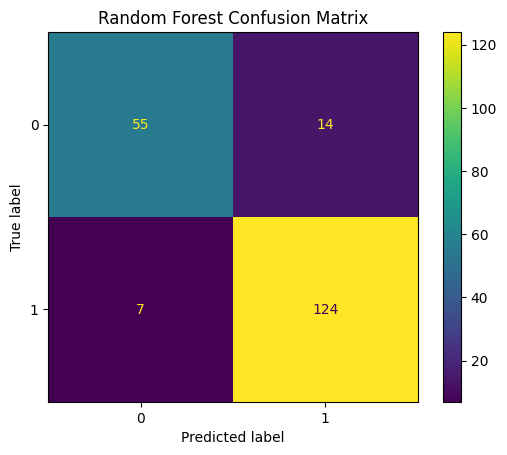

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_estimator(
    best_rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "../visuals/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

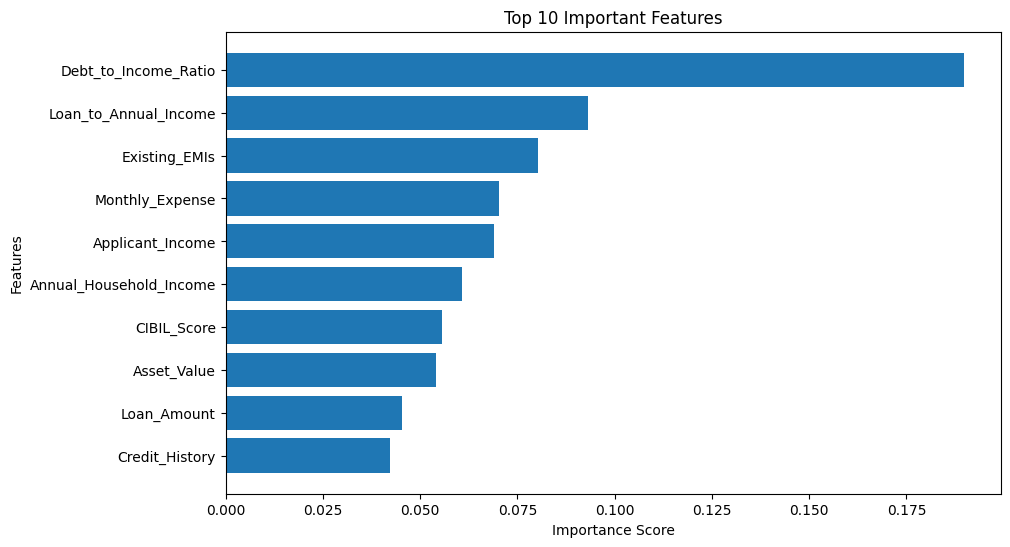

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.savefig(
    "../visuals/top_10_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

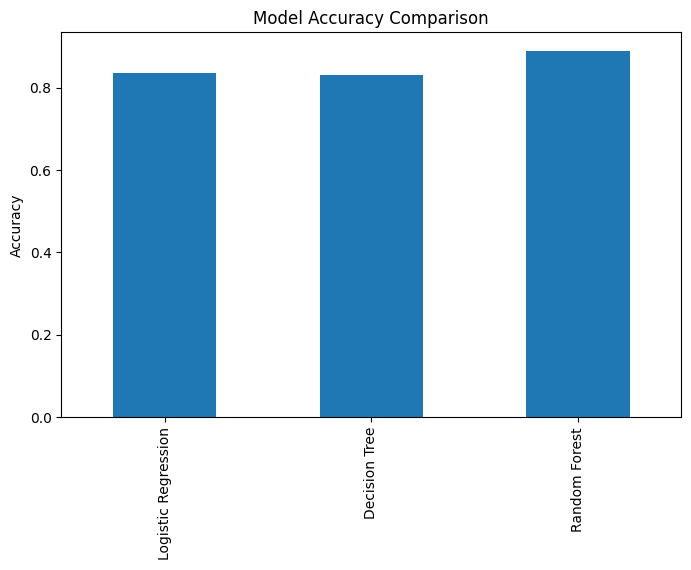

In [57]:
comparison_plot = comparison_df.T

comparison_plot["Accuracy"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.savefig(
    "../visuals/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
import joblib

joblib.dump(
    best_rf_model,
    "../models/loan_approval_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
